In [7]:
# pip install gurobipy   # if you have Gurobi available
import dwave_networkx as dnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.transform import resize
import pandas as pd
import os
from torchvision import datasets, transforms
import dwave.system
import dimod
from dwave.samplers import SimulatedAnnealingSampler

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import dimod
import itertools

In [8]:

def build_and_solve(K, V_target, H_target, tee=False):
    # Build Zephyr graph
    G = dnx.zephyr_graph(K)
    nodes = sorted(G.nodes())
    n = len(nodes)
    node_index = {i: idx for idx, i in enumerate(nodes)}

    edges = sorted(set((min(u, v), max(u, v)) for u, v in G.edges()))

    adj = {i: set() for i in nodes}
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)

    P = edges.copy()

    triples = []
    for (k, l) in P:
        common_neighbors = set(adj[k]).intersection(adj[l])
        for i in common_neighbors:
            triples.append((i, k, l))
    triples = list(set(triples))

    if not (0 <= V_target <= n):
        raise ValueError("V_target out of range")
    if not (0 <= H_target <= n):
        raise ValueError("H_target out of range")
    f_required = (n - V_target) - H_target
    if f_required < 0:
        raise ValueError(f"Impossible targets: need nonnegative fusions, got {f_required}")

    
    # Build Gurobi model
    
    m = gp.Model("NodeLabelOptimization")

    # --- Variables ---
    relax = False  # <-- toggle

    vtype = GRB.CONTINUOUS if relax else GRB.BINARY
    
    x = {i: m.addVar(vtype=vtype, lb=0, ub=1, name=f"x_{i}") for i in nodes}
    z = {p: m.addVar(vtype=vtype, lb=0, ub=1, name=f"z_{p[0]}_{p[1]}") for p in P}
    y = {e: m.addVar(vtype=vtype, lb=0, ub=1, name=f"y_{e[0]}_{e[1]}") for e in edges}
    u = {t: m.addVar(vtype=vtype, lb=0, ub=1, name=f"u_{t[0]}_{t[1]}_{t[2]}") for t in triples}
    t_var = m.addVar(vtype=GRB.INTEGER, lb=0, name="t")
    
    # New variable for minimum visible connections
    min_visible_connections = m.addVar(vtype=GRB.INTEGER, lb=0, name="min_vis_conn")

    m.update()
    
    # Constraints
    
    # 1) Visible node count
    m.addConstr(gp.quicksum(x[i] for i in nodes) == V_target, "visible_count")

    # 2) Hidden target: sum x_i + sum z_kl = n - H_target
    m.addConstr(gp.quicksum(x[i] for i in nodes) + gp.quicksum(z[p] for p in P) == n - H_target, "hidden_target")

    # 3) Fusion only among hidden nodes
    for (k, l) in P:
        m.addConstr(z[(k, l)] <= 1 - x[k], f"fusion1_{k}_{l}")
        m.addConstr(z[(k, l)] <= 1 - x[l], f"fusion2_{k}_{l}")

    # 4) Matching constraint: node participates in ≤ 1 fusion
    # for i in nodes:
    #     nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
    #     if nbrs:
    #         m.addConstr(gp.quicksum(z[p] for p in nbrs) <= 1 - x[i], f"match_{i}")

    # 5) Linearize y_ij = |x_i - x_j|
    for (i, j) in edges:
        m.addConstr(y[(i, j)] >= x[i] - x[j])
        m.addConstr(y[(i, j)] >= x[j] - x[i])
        m.addConstr(y[(i, j)] <= x[i] + x[j])
        m.addConstr(y[(i, j)] <= 2 - (x[i] + x[j]))

    # 6) Linearize u_{i,kl} = x_i * z_{kl}
    for (i, k, l) in triples:
        m.addConstr(u[(i, k, l)] <= x[i])
        m.addConstr(u[(i, k, l)] <= z[(k, l)])
        m.addConstr(u[(i, k, l)] >= x[i] + z[(k, l)] - 1)

    # 7) Maximin constraint for V-H edges: t <= c_i + M*x_i
    max_deg = max(len(adj[i]) for i in nodes)
    M = max_deg
    for i in nodes:
        c_i0 = gp.quicksum(y[(min(i, j), max(i, j))] for j in adj[i])
        losses = gp.quicksum(u[t] for t in triples if t[0] == i)
        c_i_expr = c_i0 - losses
        m.addConstr(t_var <= c_i_expr + M * x[i], f"maximin_{i}")

    # 8) Upper bound for t
    m.addConstr(t_var <= max_deg, "t_upper")
    
    # 9) NEW: Constrain t >= 4 (5 works, but then we lose a lot in vis)
    m.addConstr(t_var >= 4, "t_lower_bound")
    
    # 10) NEW: For visible nodes, compute connections to other visible nodes
    # For each visible node i, count edges to other visible nodes
    # Connection is (1 - y_ij) when both are visible (since y_ij = 0 when both have same label)
    for i in nodes:
        visible_connections = gp.LinExpr()
        for j in adj[i]:
            edge_key = (min(i, j), max(i, j))
            # This edge connects two visible nodes if x[i]=1, x[j]=1, and y[edge]=0
            # We want to count: x[i] * x[j] * (1 - y[edge])
            # This is non-linear, so we linearize it
            # For visible-visible connections: y=0, so we count edges where both are visible
            # Simpler approach: for visible node i, sum of (x[j] * (1 - y[edge]))
            # Even simpler: total neighbors that are visible = sum x[j] for j in neighbors
            # But we want to account for the fact that y represents absolute difference
            # When both are visible (x[i]=1, x[j]=1), then y should be 0
            # So visible-visible connections = x[j] * (1 - y[edge]) ≈ x[j] when both visible
            
            # Count visible neighbors: this is x[j] for each neighbor j
            visible_connections += x[j]
        
        # min_visible_connections <= visible_connections + M*(1-x[i])
        # If x[i]=1 (visible), then min_visible_connections <= visible_connections
        # If x[i]=0 (hidden), constraint is relaxed
        m.addConstr(min_visible_connections <= visible_connections + M * (1 - x[i]), f"min_vis_conn_{i}")

    # Objective: maximize minimum visible connections
    m.setObjective(min_visible_connections, GRB.MAXIMIZE)

   
    # Solve
    m.setParam('TimeLimit', 21600.0)
    m.setParam('OutputFlag', 1 if tee else 0)
    m.setParam('MIPGap', 0)

    print(f"K={K}, n={n}, V_target={V_target}, H_target={H_target}")
    print(f"f_required = {(n - V_target) - H_target}")
    print(f"Max possible fusions (n/2) = {n//2}")
    print(f"Total edges = {len(edges)}")
    m.optimize()

    status = m.status
    print(f"Solver status: {status}")

    # Extract results
    if m.status != GRB.OPTIMAL and m.status != GRB.SUBOPTIMAL:
        print(f"Warning: No optimal solution found. Status: {status}")
        return None
   
    # Get solution values
    x_vals = {i: x[i].X for i in nodes}
    z_vals = {p: z[p].X for p in P}
    y_vals = {e: y[e].X for e in edges}
    u_vals = {t: u[t].X for t in triples}
    t_val = t_var.X
    min_vis_conn_val = min_visible_connections.X

    # quick summaries
    print("SUM x (float) =", sum(x_vals.values()))
    print("SUM z (float) =", sum(z_vals.values()))
    print("SUM y (float) =", sum(y_vals.values()))
    print("t (float) =", t_val)
    print("min_visible_connections =", min_vis_conn_val)

    # show top nonzero vars (for debugging)
    print("Top x (nonzero):", [(i, round(x_vals[i],3)) for i in nodes if x_vals[i] > 1e-6][:20])
    print("Top z (nonzero):", [(p, round(z_vals[p],3)) for p in P if z_vals[p] > 1e-6][:20])
    print("Top y (nonzero):", [(e, round(y_vals[e],3)) for e in edges if y_vals[e] > 1e-6][:20])

    # Compute effective c_i
    c0 = {}
    losses = {}
    c_eff = {}
    for i in nodes:
        nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
        c0[i] = sum(y_vals.get(p, 0.0) for p in nbrs)
        losses[i] = sum(u_vals.get(t, 0.0) for t in triples if t[0] == i)
        c_eff[i] = c0[i] - losses[i]

  
    # Build contracted graph (apply fusions)
   
    # Build contracted graph (apply fusions)
    G_contracted = G.copy()
    fused_map = {}  # maps original node → final representative

    # Group fusions by connected components
    fusion_edges = [(k, l) for (k, l), val in z_vals.items() if val > 0.99]  # use threshold for float tolerance

    # Build fusion graph to find connected components
    fusion_graph = nx.Graph()
    fusion_graph.add_nodes_from(nodes)
    fusion_graph.add_edges_from(fusion_edges)

    # Each connected component gets fused into one node
    for component in nx.connected_components(fusion_graph):
        if len(component) == 1:
            continue  # singleton, no fusion needed
        
        # Pick representative (e.g., smallest node ID)
        rep = min(component)
        rep_name = "_".join(map(str, sorted(component)))
        
        # Collect all neighbors from all nodes in component
        all_neighbors = set()
        for node in component:
            if node in G_contracted:
                all_neighbors.update(G_contracted.neighbors(node))
        
        # Remove nodes being fused from neighbor set
        all_neighbors -= component
        
        # Add new representative node
        if rep_name not in G_contracted:
            G_contracted.add_node(rep_name)
        
        # Connect representative to all external neighbors
        for nb in all_neighbors:
            if nb not in component:  # don't self-loop
                G_contracted.add_edge(rep_name, nb)
        
        # Remove original nodes
        for node in component:
            if node in G_contracted:
                G_contracted.remove_node(node)
            fused_map[node] = rep_name

    print(f"Objective: min_visible_connections = {min_vis_conn_val}")
    print(f"V-H cross-edges constraint t = {t_val} (constrained >= 5)")
    print("Visible nodes (x_i=1):", [i for i, xv in x_vals.items() if xv > 0.99])
    print("Fusions (z_{k,l}=1):", [p for p, zv in z_vals.items() if zv > 0.99])
    print("Effective cross-edges per node (c_eff):")
    for i in nodes:
        print(f" node {i}: x={x_vals[i]}, c0={c0[i]}, losses={losses[i]}, c_eff={c_eff[i]}")

    return {
        "model": m,
        "x": x_vals,
        "z": z_vals,
        "y": y_vals,
        "u": u_vals,
        "t": t_val,
        "min_visible_connections": min_vis_conn_val,
        "c0": c0,
        "losses": losses,
        "c_eff": c_eff,
        "G_original": G,
        "G_contracted": G_contracted,
        "fused_map": fused_map
    }


In [9]:
K = 3
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
print('K =', K, 'n =', n, 'n/K =', n/K, 'n/(32*K^2) =', n/(32*K**2+16*K))
# set targets
V_target = 144 # e.g., 20% visible
H_target =  32  # choose a hidden target by requiring 2 fusions for demo
sol = build_and_solve(K=K, V_target=V_target, H_target=H_target, tee=True)
x_vals = sol["x"]
G_new = sol["G_contracted"]
print(x_vals)

K = 3 n = 336 n/K = 112.0 n/(32*K^2) = 1.0
Set parameter TimeLimit to value 21600
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
K=3, n=336, V_target=144, H_target=32
f_required = 160
Max possible fusions (n/2) = 168
Total edges = 2808
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (armlinux64 - "Ubuntu 24.04.3 LTS")
Set parameter TimeLimit to value 21600
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
K=3, n=336, V_target=144, H_target=32
f_required = 160
Max possible fusions (n/2) = 168
Total edges = 2808
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (armlinux64 - "Ubuntu 24.04.3 LTS")

CPU model: ARM64
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  21600
MIPGap  0

Academic license 2573800 - for non-commercial use only - registered to ke___@berkeley.edu
Optimize a model with 36820 rows, 12386 columns and 112442 nonzeros
Model fingerprint: 0xc289a0a4
Variable types: 0 con

TypeError: 'NoneType' object is not subscriptable

In [ ]:
def apply_fusions_to_graph(G_original, x_vals, z_vals):
    """
    Apply fusion solution to the graph, handling multiple fusions per node properly.
    """
    G = G_original.copy()
    nodes = sorted(G.nodes())
    
    # Step 1: Identify visible nodes
    visible_nodes = [i for i in nodes if x_vals[i] > 0.5]
    
    # Step 2: Build fusion groups (nodes that should be merged together)
    # Use Union-Find to handle transitive fusions
    parent = {i: i for i in nodes}
    
    def find(i):
        if parent[i] != i:
            parent[i] = find(parent[i])
        return parent[i]
    
    def union(i, j):
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pj] = pi
    
    # Group nodes that should be fused together
    for (k, l), val in z_vals.items():
        if val > 0.5:  # Fusion is active
            union(k, l)
    
    # Step 3: Create fusion groups
    fusion_groups = {}
    for i in nodes:
        root = find(i)
        if root not in fusion_groups:
            fusion_groups[root] = []
        fusion_groups[root].append(i)
    
    # Step 4: Contract graph
    G_contracted = G.copy()
    node_mapping = {}  # old_node -> new_node (or fusion_representative)
    
    for root, group in fusion_groups.items():
        if len(group) > 1:
            # This is a fusion group - contract them
            representative = min(group)  # Pick lowest ID as representative
            
            # Collect all neighbors
            all_neighbors = set()
            for node in group:
                all_neighbors.update(G_contracted.neighbors(node))
            all_neighbors -= set(group)  # Remove self-connections
            
            # Remove all nodes in group except representative
            for node in group:
                node_mapping[node] = representative
                if node != representative and node in G_contracted:
                    G_contracted.remove_node(node)
            
            # Add edges from representative to all neighbors
            for neighbor in all_neighbors:
                G_contracted.add_edge(representative, neighbor)
        else:
            node_mapping[group[0]] = group[0]
    
    # Step 5: Update visible node list based on mapping
    visible_nodes_contracted = list(set(node_mapping[v] for v in visible_nodes))
    hidden_nodes_contracted = [n for n in G_contracted.nodes() if n not in visible_nodes_contracted]
    
    return G_contracted, visible_nodes_contracted, hidden_nodes_contracted, node_mapping

def visualize_contracted_graph(G_contracted, visible_nodes, hidden_nodes, 
                               use_zephyr_layout=True):
    """
    Visualize the contracted graph showing visible vs hidden nodes.
    """
    # Create x_sol format for compatibility with analyze_maxcut
    x_sol = {}
    for node in G_contracted.nodes():
        x_sol[node] = 1 if node in visible_nodes else 0
    
    # Count cross-edges (visible-hidden connections)
    cross_edges = []
    for u, v in G_contracted.edges():
        if x_sol[u] != x_sol[v]:
            cross_edges.append((u, v))
    
    print(f"→ Cross-edges (V-H): {len(cross_edges)} out of {G_contracted.number_of_edges()}")
    print(f"→ Visible nodes: {len(visible_nodes)}")
    print(f"→ Hidden nodes: {len(hidden_nodes)}")
    
    # Visualize
    if use_zephyr_layout:
        # Use spring layout since Zephyr layout won't work after contraction
        pos = nx.spring_layout(G_contracted, seed=42, k=0.5)
    else:
        pos = nx.spring_layout(G_contracted, seed=42)
    
    node_colors = ['red' if node in visible_nodes else 'blue' 
                   for node in G_contracted.nodes()]
    
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G_contracted, pos, node_color=node_colors, 
                          node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G_contracted, pos, edge_color='lightgray', 
                          alpha=0.3, width=0.5)
    nx.draw_networkx_edges(G_contracted, pos, edgelist=cross_edges, 
                          edge_color='green', alpha=0.6, width=1.0)
    
    # Add legend
    red_patch = plt.Line2D([0], [0], marker='o', color='w', 
                           markerfacecolor='red', markersize=10, label='Visible')
    blue_patch = plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor='blue', markersize=10, label='Hidden')
    green_line = plt.Line2D([0], [0], color='green', linewidth=2, 
                            label='V-H edges')
    plt.legend(handles=[red_patch, blue_patch, green_line], loc='upper right')
    
    plt.title(f"Contracted Graph: {len(visible_nodes)} Visible, "
              f"{len(hidden_nodes)} Hidden\n"
              f"{len(cross_edges)} cross-edges")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return x_sol

# After: G_contracted, visible_nodes, hidden_nodes, node_mapping = apply_fusions_to_graph(...)

# Relabel graph nodes to be consecutive: visible first (0 to V-1), then hidden (V to V+H-1)
def relabel_for_training(G_contracted, visible_nodes, hidden_nodes):
    """
    Relabel graph so visible nodes are [0, num_visible-1] 
    and hidden nodes are [num_visible, num_visible+num_hidden-1]
    """
    old_to_new = {}
    
    # Visible nodes get IDs 0 to len(visible_nodes)-1
    for new_id, old_id in enumerate(sorted(visible_nodes)):
        old_to_new[old_id] = new_id
    
    # Hidden nodes get IDs starting from len(visible_nodes)
    offset = len(visible_nodes)
    for new_id, old_id in enumerate(sorted(hidden_nodes)):
        old_to_new[old_id] = offset + new_id
    
    G_relabeled = nx.relabel_nodes(G_contracted, old_to_new, copy=True)
    
    visible_new = list(range(len(visible_nodes)))
    hidden_new = list(range(len(visible_nodes), len(visible_nodes) + len(hidden_nodes)))
    
    return G_relabeled, visible_new, hidden_new, old_to_new




# Add this AFTER: sol = build_and_solve(K=K, V_target=V_target, H_target=H_target, tee=True)

G_contracted, visible_nodes, hidden_nodes, node_mapping = apply_fusions_to_graph(
    sol["G_original"], 
    sol["x"], 
    sol["z"]
)

print(f"\nAfter fusion:")
print(f"  Original nodes: {sol['G_original'].number_of_nodes()}")
print(f"  Contracted nodes: {G_contracted.number_of_nodes()}")
print(f"  Visible: {len(visible_nodes)}")
print(f"  Hidden: {len(hidden_nodes)}")
print(f"  Expected hidden: {H_target}")

# 3. Relabel for training
G, visible_nodes, hidden_nodes, relabel_mapping = relabel_for_training(
    G_contracted, visible_nodes, hidden_nodes
)

print(f"\nRelabeled graph:")
print(f"  Visible node IDs: 0 to {len(visible_nodes)-1}")
print(f"  Hidden node IDs: {len(visible_nodes)} to {len(visible_nodes)+len(hidden_nodes)-1}")
# # Now use G_contracted as your G for the rest of the pipeline
# G = G_contracted

# 4. Create training structures
# Create vh_nodearray (1 for visible, 0 for hidden)
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int)

# Mark visible nodes as 1
for v in visible_nodes:
    vh_nodearray[v] = 1

# Create node_labels dictionary
node_labels = {i: ('visible' if vh_nodearray[i] == 1 else 'hidden') 
               for i in range(n)}

# Update global variables
NUM_VISIBLE = len(visible_nodes)
NUM_HIDDEN = len(hidden_nodes)

print(f"\n✓ Ready for training:")
print(f"  Total nodes: {n}")
print(f"  Visible nodes: {NUM_VISIBLE}")
print(f"  Hidden nodes: {NUM_HIDDEN}")
print(f"  vh_nodearray shape: {vh_nodearray.shape}")

# Annotate graph with layer info
for v in visible_nodes:
    G.nodes[v]["layer"] = "visible"
for h in hidden_nodes:
    G.nodes[h]["layer"] = "hidden"


After fusion:
  Original nodes: 336
  Contracted nodes: 205
  Visible: 144
  Hidden: 61
  Expected hidden: 32

Relabeled graph:
  Visible node IDs: 0 to 143
  Hidden node IDs: 144 to 204

✓ Ready for training:
  Total nodes: 205
  Visible nodes: 144
  Hidden nodes: 61
  vh_nodearray shape: (205,)


→ Cross-edges (V-H): 758 out of 1426
→ Visible nodes: 144
→ Hidden nodes: 61


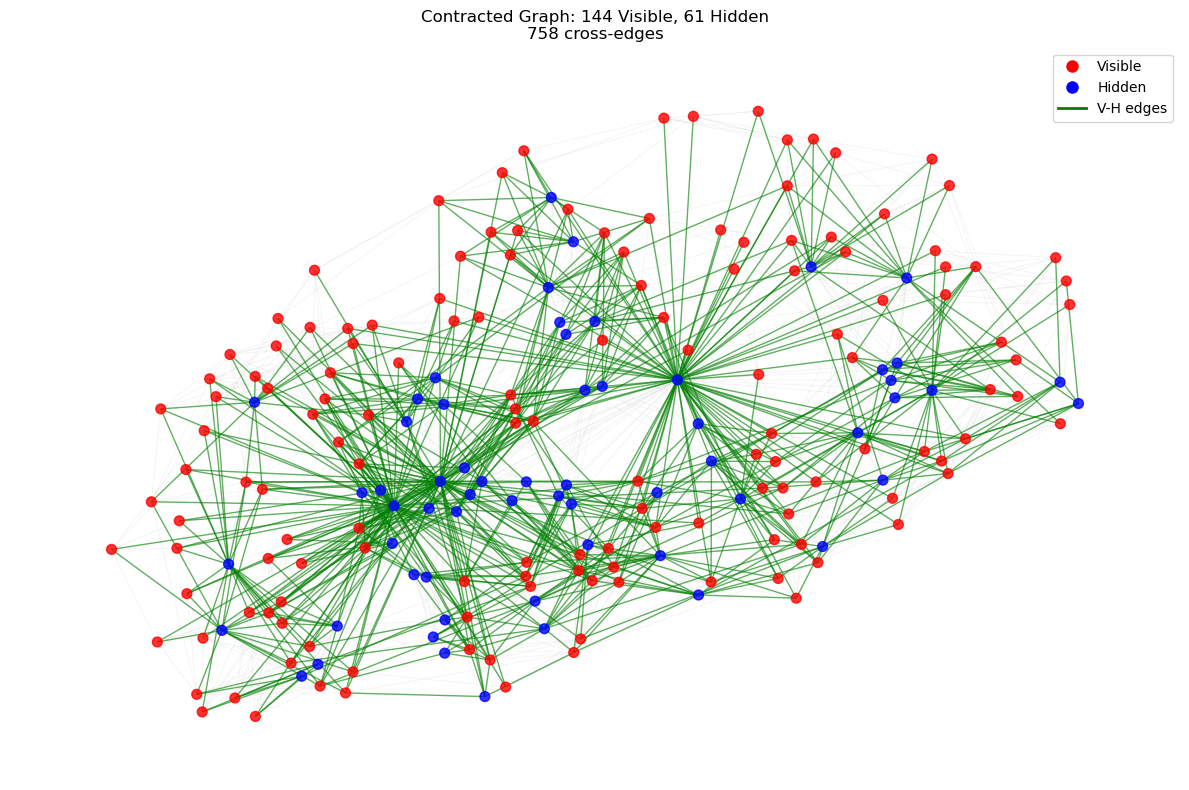

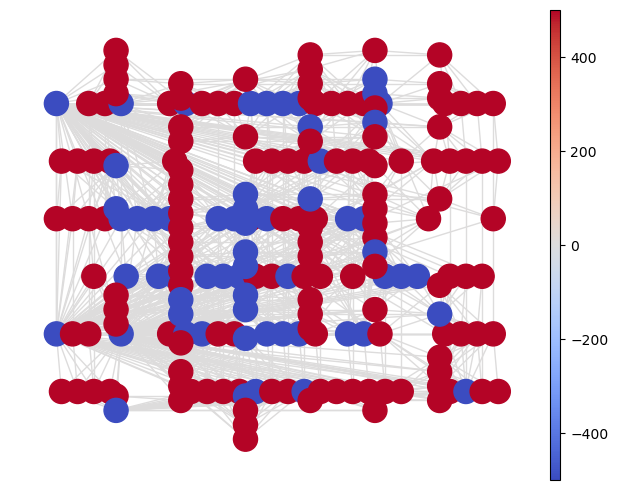

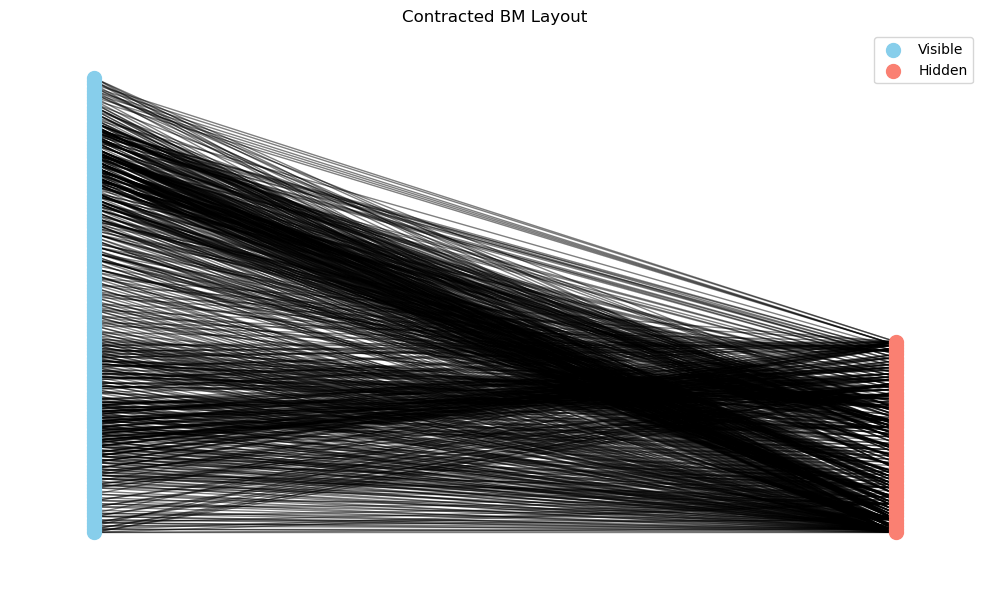

In [ ]:
from bolmaqua import *
# Visualize the contracted, relabeled graph
x_sol = visualize_contracted_graph(G, visible_nodes, hidden_nodes, use_zephyr_layout=False)

# Also try your original Zephyr visualization (if it works with contracted graph)
try:
    draw_zephyr_hidden_visible(G, vh_nodearray)
except Exception as e:
    print(f"Note: Zephyr visualization doesn't work on contracted graph: {e}")

# Use the bipartite layout from your bolmaqua.py
visualize_bm_bipartite_layout(G, node_labels, title="Contracted BM Layout")

Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([200, 144])


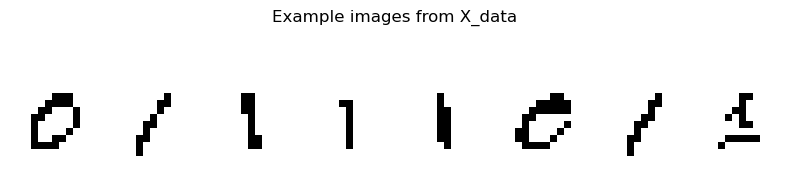

In [ ]:

# --- Dataset Loading ---
# Using torchvision to download MNIST and then resize
def generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE, cutoff=0.5):
    """
    Generates downsized MNIST .npy files (from torchvision MNIST, not CSV).
    Resizes 28x28 MNIST images to `grid_shape` (e.g., 12x12, 13x13).
    Saves features and labels as .npy for reuse.
    """
    os.makedirs(output_dir, exist_ok=True)

    def process_dataset(dataset, cutoff):
        downsized, labels = [], []
        for img, label in dataset:
            # torchvision MNIST returns a PIL image unless transform is ToTensor
            img_np = np.array(img, dtype=np.float32)

            # If shape is (28,28,1), squeeze it
            if img_np.ndim == 3:
                img_np = img_np.squeeze(-1)

            img_np = img_np / 255.0  # scale to [0,1]
            img_small = resize(img_np, grid_shape, order=1, anti_aliasing=True, preserve_range=True)

            img_bin = (img_small >= cutoff).astype(np.uint8)
            downsized.append(img_bin.flatten())
            labels.append(label)
        return np.array(downsized), np.array(labels)

    # Load MNIST from torchvision (downloads automatically if not present)
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=None)
    test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

    for split, dataset in [("train", train_data), ("test", test_data)]:
        out_feats = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}feats.npy")
        out_labels = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}labels.npy")
        if not (os.path.exists(out_feats) and os.path.exists(out_labels)):
            print(f"Generating {out_feats} and {out_labels}...")
            feats, labels = process_dataset(dataset, cutoff)
            print("Processed feats shape:", feats.shape) # Debug print
            np.save(out_feats, feats)
            np.save(out_labels, labels)
        else:
            print(f"Found existing {out_feats} and {out_labels}.")

    return (
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainfeats.npy")),
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainlabels.npy"))
    )



# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
num_images_to_use = 200
mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())
# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float()
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
dummy_labels = torch.zeros(len(X_data))  
dataset = torch.utils.data.TensorDataset(X_data, dummy_labels)

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

Graph has 205 nodes and 1426 edges
V-V edges: 409, H-H edges: 259, V-H edges: 758


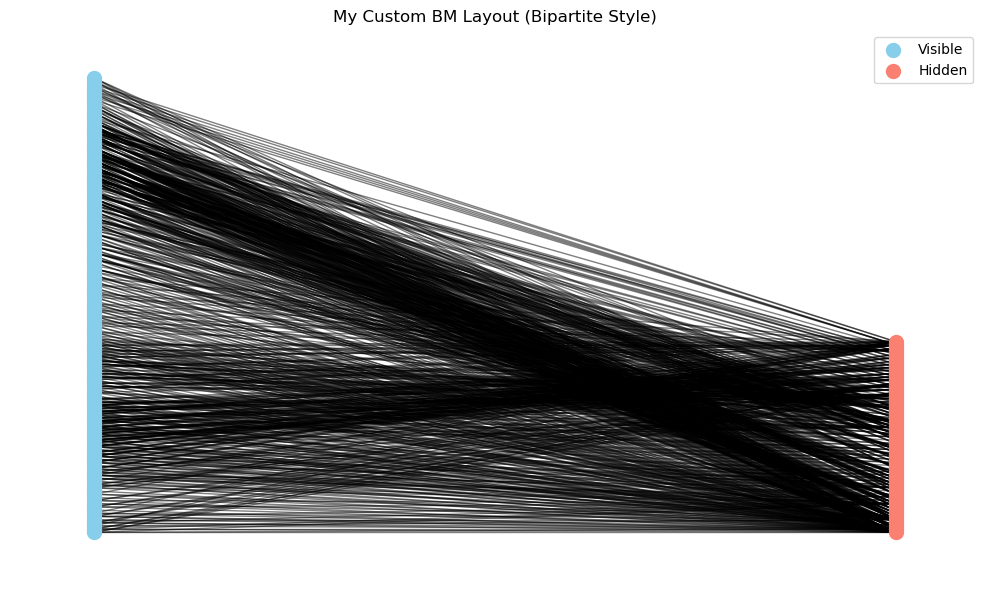

Building Boltzmann Machine from graph... 🏗️
Sanity check:
  dataset feature dim: 144
  model num_visible   : 144
  model num_hidden    : 61
  W_vh shape (should be V x H): (144, 61)
Starting PCD training on cpu for 50 epochs... 🏋️
Epoch 1/50 | Avg PCD Loss: 0.0000 | PLL: -0.6453
Epoch 2/50 | Avg PCD Loss: 0.0000 | PLL: -0.5800
Epoch 3/50 | Avg PCD Loss: 0.0000 | PLL: -0.5448
Epoch 4/50 | Avg PCD Loss: 0.0000 | PLL: -0.4940
Epoch 5/50 | Avg PCD Loss: 0.0000 | PLL: -0.4389
Epoch 6/50 | Avg PCD Loss: 0.0000 | PLL: -0.4186
Epoch 7/50 | Avg PCD Loss: 0.0000 | PLL: -0.3576
Epoch 8/50 | Avg PCD Loss: 0.0000 | PLL: -0.3710
Epoch 9/50 | Avg PCD Loss: 0.0000 | PLL: -0.3326
Epoch 10/50 | Avg PCD Loss: 0.0000 | PLL: -0.3706
Epoch 11/50 | Avg PCD Loss: 0.0000 | PLL: -0.3355
Epoch 12/50 | Avg PCD Loss: 0.0000 | PLL: -0.3316
Epoch 13/50 | Avg PCD Loss: 0.0000 | PLL: -0.3334
Epoch 14/50 | Avg PCD Loss: 0.0000 | PLL: -0.3102
Epoch 15/50 | Avg PCD Loss: 0.0000 | PLL: -0.2484
Epoch 16/50 | Avg PCD Loss: 

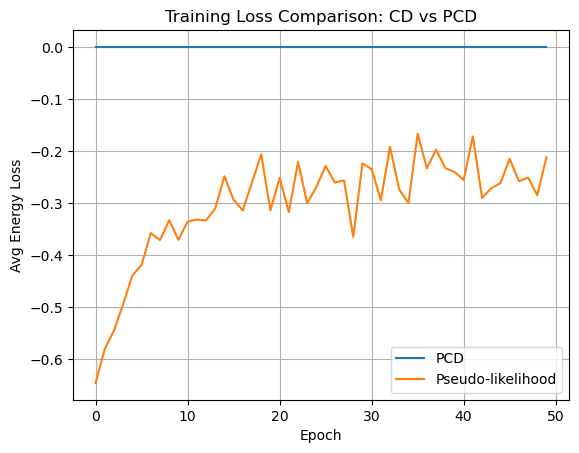

In [ ]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.00175 # You can change this value for experiments 
l2_amount = 0.002 # L2 regularization amount
num_epochs = 50
batch_size = 20
num_gibbs_steps = 150
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



# Print some graph statistics
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)


# Sanity check
print("Sanity check:")
print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
W_vv.zero_() # disables v-v connections
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)


# --- Training ---
optimizer_pcd = torch.optim.Adam(model_pcd.parameters(), lr=step_size, weight_decay=l2_amount)
pcd_losses, pll_values = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, 
                                         batch_size=batch_size, step_size=step_size)

# check_fusion_strength(model_pcd, fused_pairs_remapped)
# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.plot(pll_values, label="Pseudo-likelihood")
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()

Running Gibbs sampler for 10 samples, 500 burn-in steps each... 🔥
  Gibbs sample 1/10
  Gibbs sample 2/10
  Gibbs sample 3/10
  Gibbs sample 4/10
  Gibbs sample 5/10
  Gibbs sample 6/10
  Gibbs sample 7/10
  Gibbs sample 8/10
  Gibbs sample 9/10
  Gibbs sample 10/10
Gibbs sampling complete.

Displaying generated images... 🖼️


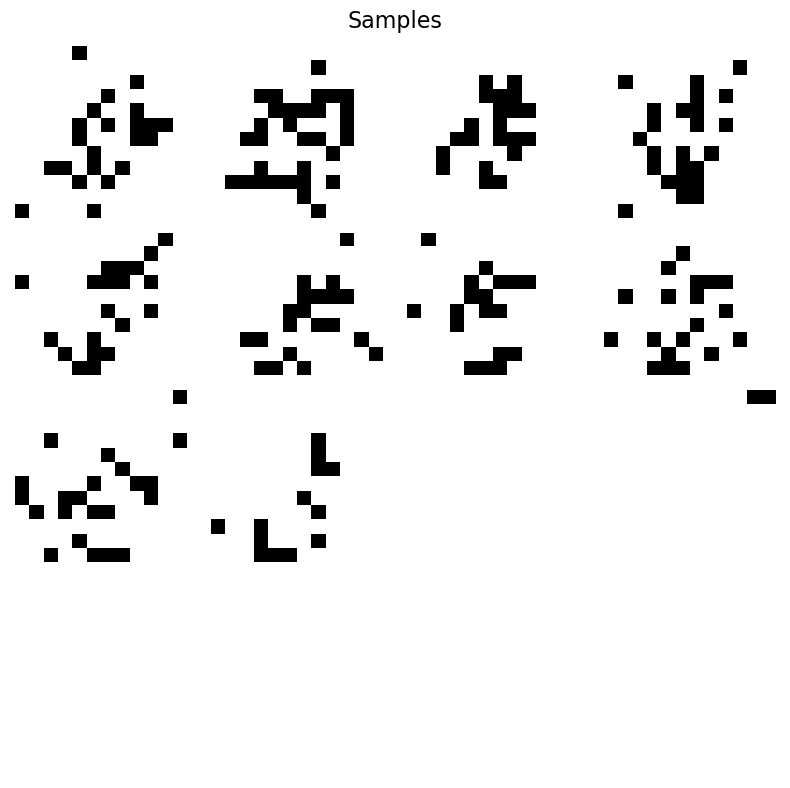

In [ ]:
#--- Sampling & Visualization ---
num_gen_samples = 10
burn_in = 500


#need to find a way to speed up these sampling functions, so slow
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples")


--- Improving samples with Tabu Search ---

Displaying Tabu Search improved images... 🖼️


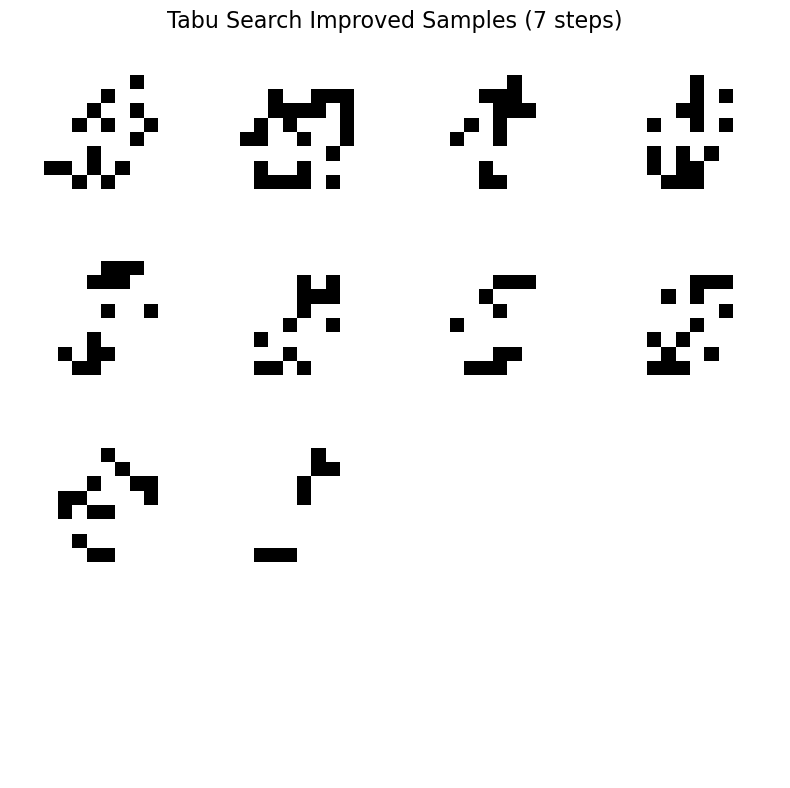

In [ ]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 7
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")